# Project 2D flat MNIST images onto the sphere

This notebook mirrors the upstream `MNIST2healpix` demo, but uses the HuggingFace `datasets` library to load MNIST and the local `projections` module (NEST-ordered output) instead of NNhealpix.

Run with the `examples` extra installed: `uv sync --extra examples`.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline

from datasets import load_dataset

from projections import img2healpix, img2healpix_planar

/lustre/ific.uv.es/ml/ific088/github/HEAL-SWIN-nnx/.claude/worktrees/mnist-healpix-examples/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load one digit from MNIST

HuggingFace returns PIL images, so we convert to a numpy array. We only need a single image to demonstrate the projection.

In [2]:
mnist = load_dataset('ylecun/mnist')
sample = mnist['train'][1140]
img = np.array(sample['image'], dtype=float)
print('label:', sample['label'], 'shape:', img.shape)

label: 2 shape: (28, 28)


## Planar projection

`img2healpix_planar` centers the image at `(thetac, phic)` and fills the covered HEALPix pixels by nearest-neighbour interpolation. The map is in NEST ordering, so we pass `nest=True` to `hp.mollview`.

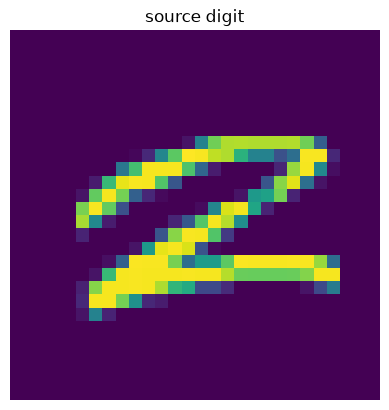

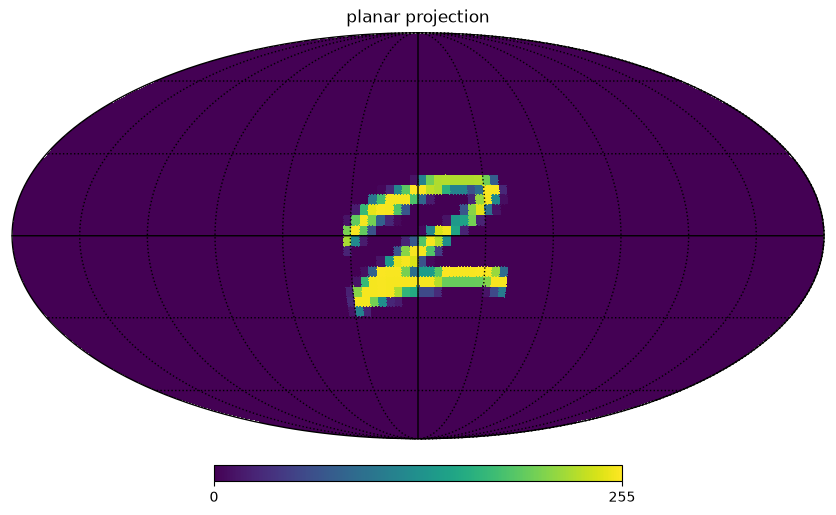

In [3]:
img_hp = img2healpix_planar(img, nside=128, thetac=90, phic=0,
                            delta_theta=100, delta_phi=100)

plt.figure(); plt.imshow(img); plt.title('source digit'); plt.axis('off')
hp.mollview(img_hp, nest=True, title='planar projection')
hp.graticule()

## Ray-traced projection and hit map

`img2healpix` fires rays through the image and bins them, returning both the map and a hit map. Plotting the hit map confirms the projection leaves no gaps within the image frame.

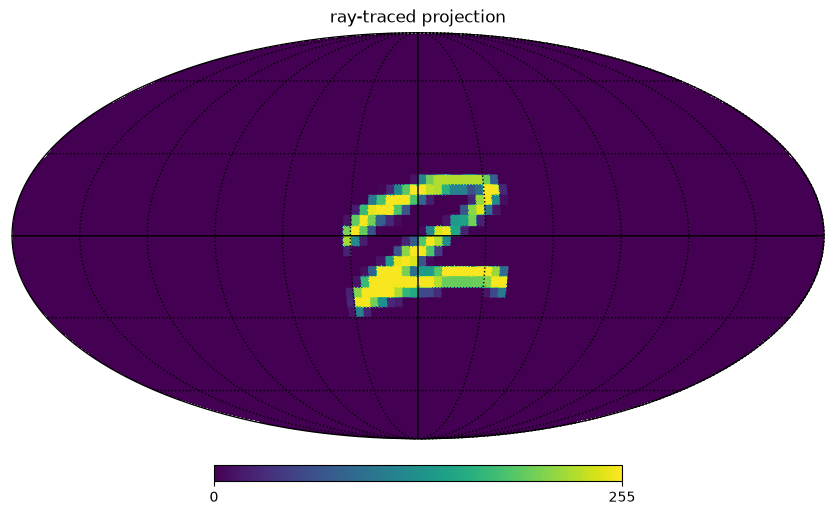

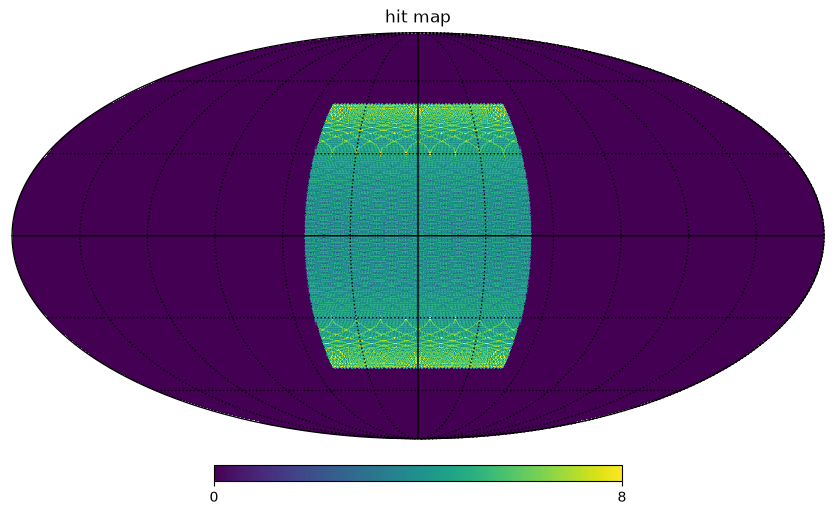

In [4]:
img_hp, img_hits = img2healpix(img, nside=128,
                               delta_theta=100, delta_phi=100)

hp.mollview(img_hp, nest=True, title='ray-traced projection')
hp.graticule()
hp.mollview(img_hits, nest=True, title='hit map')
hp.graticule()

## Wrapping around the pole

The same projection with a rotation, so the image drapes over the pole.

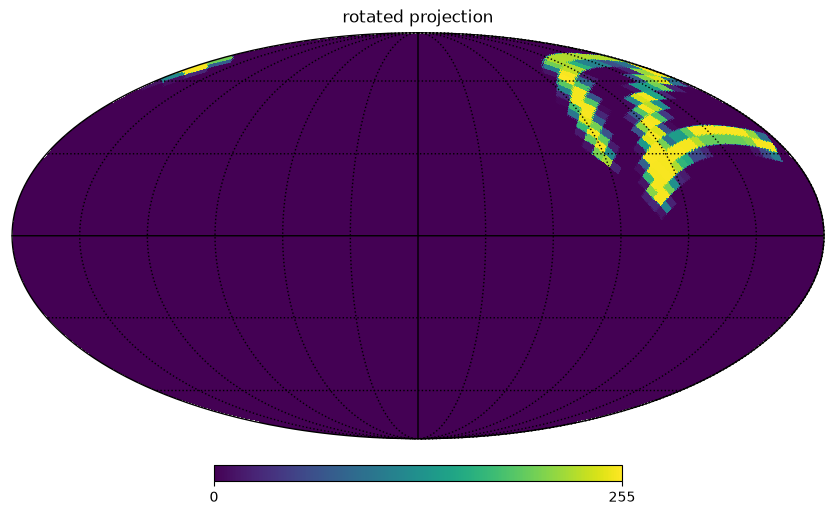

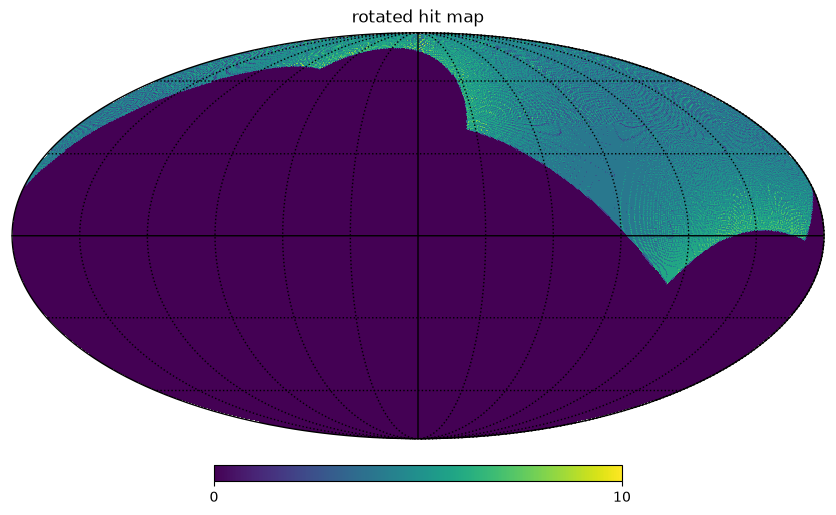

In [5]:
rot = hp.rotator.Rotator(rot=(120.0, 45.0, 30.0))
img_hp, img_hits = img2healpix(img, nside=128,
                               delta_theta=100, delta_phi=100, rot=rot)

hp.mollview(img_hp, nest=True, title='rotated projection')
hp.graticule()
hp.mollview(img_hits, nest=True, title='rotated hit map')
hp.graticule()